# Practical Deep Learning : Classification de Cellules Sanguines avec MLP

---

**Objectif :** Construire un classifieur de cellules sanguines pour detecter le paludisme.

**4 classes :**
- `red blood cell` : Cellule saine
- `ring` : Infection precoce
- `schizont` : Infection avancee
- `trophozoite` : Infection active

---

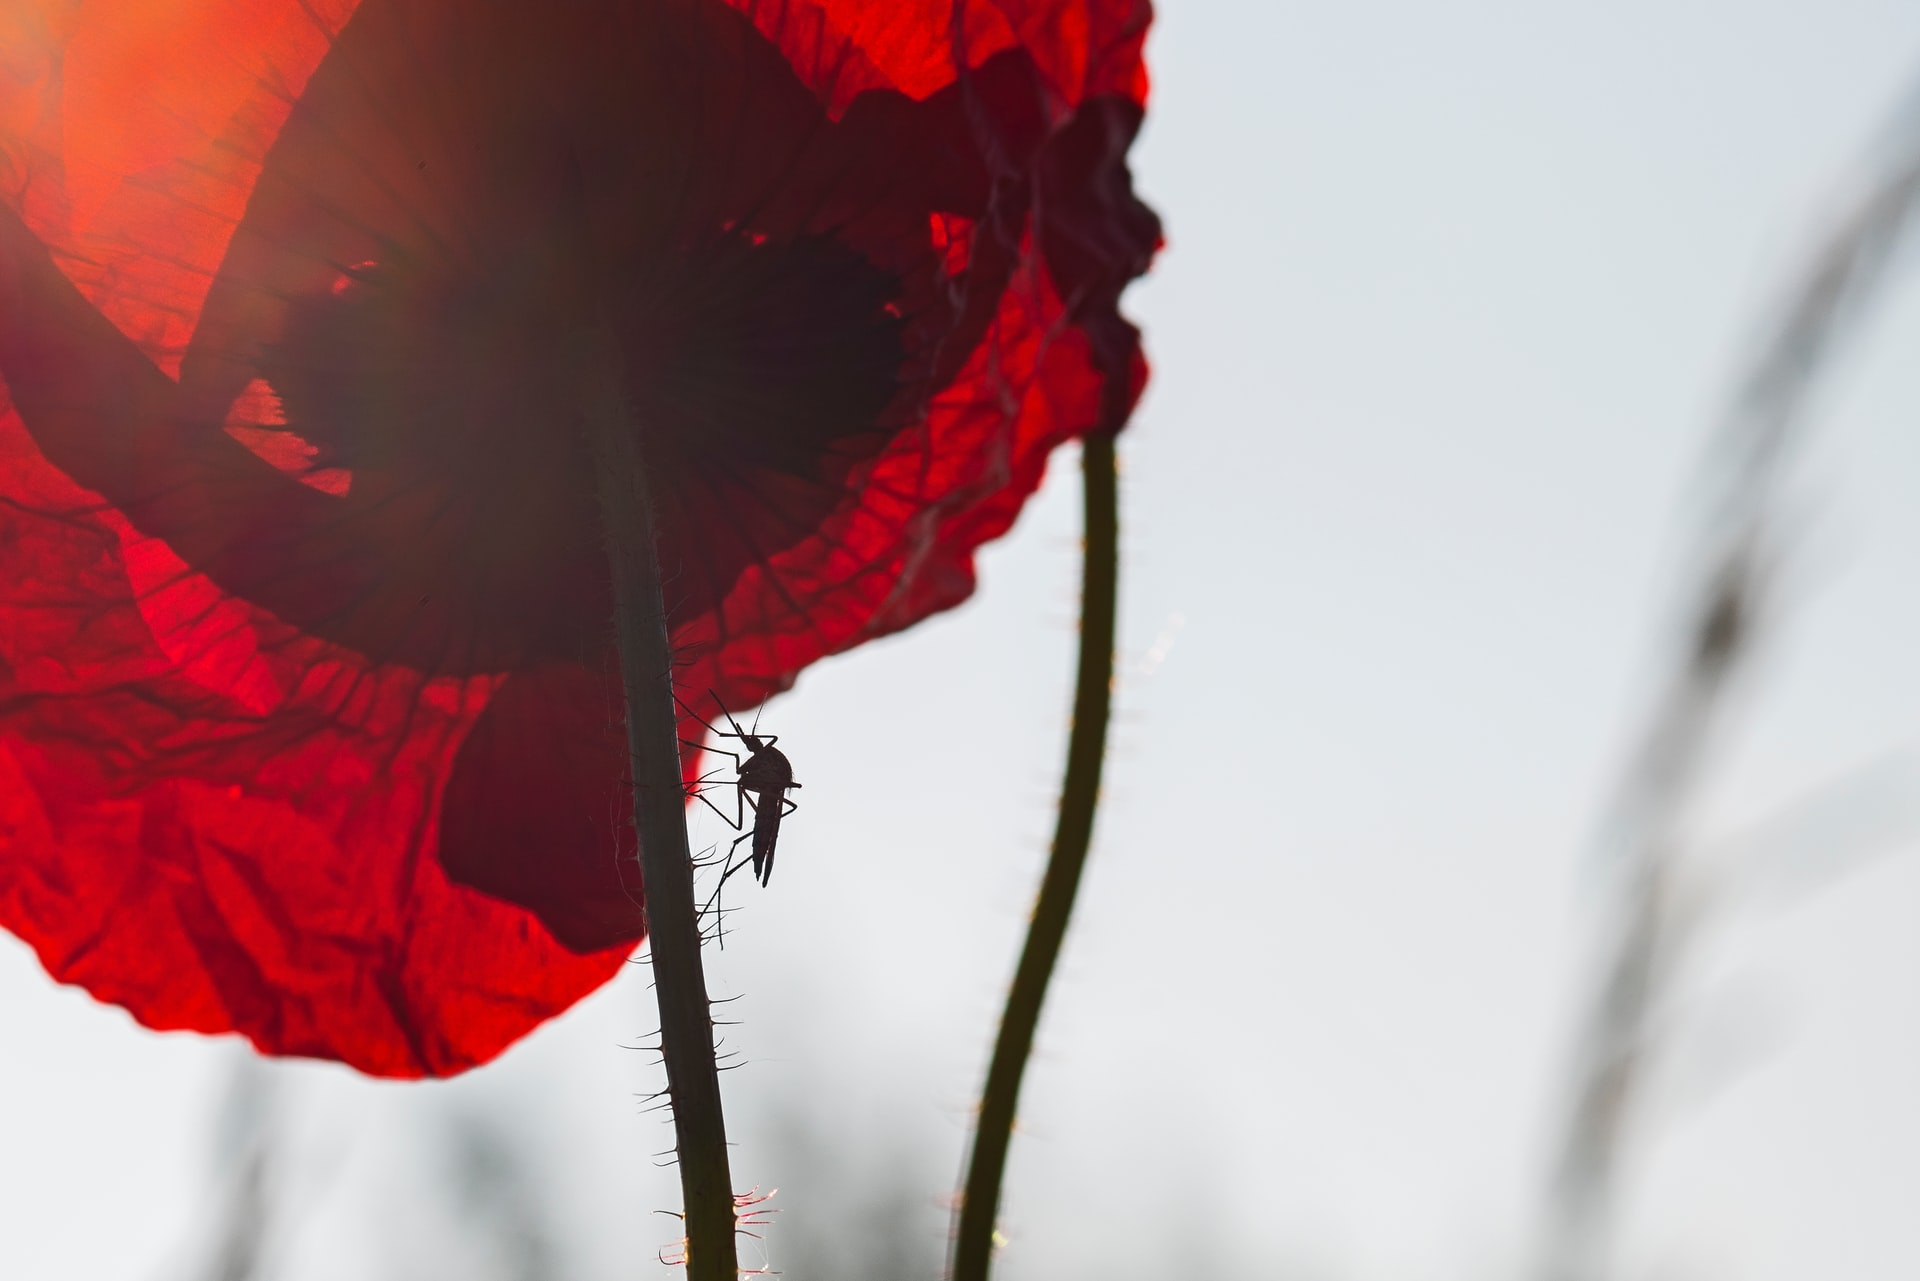

## 1. Imports

In [ ]:
# Bibliotheques de base
import ______
import ______ as np
import ______ as pd
import matplotlib.______ as plt
import ______ as sns
import ______
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
import ______ as tf
from tensorflow import ______
from tensorflow.keras import layers, models, callbacks, regularizers

# Metriques
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, 
    accuracy_score, cohen_kappa_score
)
from sklearn.utils.class_weight import compute_class_weight

# Seed pour reproductibilite
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

## 2. Configuration des Chemins et Chargement des Donnees

In [ ]:
# Chemin vers les donnees
DATA_PATH = '______'  # Chemin Kaggle
TRAIN_DIR = f'{DATA_PATH}/______'

# Charger les fichiers CSV
train_df = pd.read_csv(f'{DATA_PATH}/______.csv')
valid_df = pd.read_csv(f'{DATA_PATH}/______.csv')
holdout_df = pd.read_csv(f'{DATA_PATH}/______.csv')

print(f"Train: {len(train_df)} images")
print(f"Validation: {len(valid_df)} images")
print(f"Holdout: {len(holdout_df)} images")

In [ ]:
# Configuration
CLASS_NAMES = ['______', '______', '______', '______']
N_CLASSES = ______

IMG_HEIGHT = ______
IMG_WIDTH = ______
N_CHANNELS = ______

print(f"Classes: {CLASS_NAMES}")
print(f"Dimensions: {IMG_HEIGHT}x{IMG_WIDTH}x{N_CHANNELS}")

## 3. Exploration des Donnees

In [ ]:
# Distribution des classes
class_distribution = train_df['______'].value_counts().sort_index()

print("Distribution des classes:")
for idx, count in class_distribution.items():
    pct = 100 * count / len(train_df)
    print(f"   {CLASS_NAMES[idx]}: {count} ({pct:.1f}%)")

In [ ]:
# Visualiser quelques images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, class_name in enumerate(CLASS_NAMES):
    # Prendre une image de chaque classe
    sample = train_df[train_df['target'] == i].iloc[0]
    img_path = f"{TRAIN_DIR}/{sample['image_id']}.png"
    
    img = plt.imread(img_path)
    axes[i//2, i%2*2].imshow(img)
    axes[i//2, i%2*2].set_title(class_name)
    axes[i//2, i%2*2].axis('off')
    
    # Deuxieme exemple
    sample2 = train_df[train_df['target'] == i].iloc[1]
    img_path2 = f"{TRAIN_DIR}/{sample2['image_id']}.png"
    img2 = plt.imread(img_path2)
    axes[i//2, i%2*2+1].imshow(img2)
    axes[i//2, i%2*2+1].set_title(class_name)
    axes[i//2, i%2*2+1].axis('off')

plt.tight_layout()
plt.show()

## 4. Chargement et Preprocessing des Images

In [ ]:
def load_images(df, data_dir, img_size=(100, 100)):
    """
    Charge et normalise les images.
    """
    images = []
    labels = []
    
    for _, row in tqdm(df.iterrows(), total=len(df)):
        img_path = f"{data_dir}/{row['______']}.png"
        
        # Charger l'image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Redimensionner
        img = cv2.resize(img, img_size)
        
        # Normaliser [0,255] -> [0,1]
        img = img.astype(np.float32) / ______
        
        images.append(img)
        labels.append(row['______'])
    
    return np.array(images), np.array(labels)

In [ ]:
# Charger les donnees
print("Chargement des images...")

X_train, y_train = load_images(______, TRAIN_DIR)
X_valid, y_valid = load_images(______, TRAIN_DIR)
X_holdout, y_holdout = load_images(______, TRAIN_DIR)

print(f"\nX_train: {X_train.shape}")
print(f"X_valid: {X_valid.shape}")
print(f"X_holdout: {X_holdout.shape}")

In [ ]:
# Aplatir les images pour le MLP
# (n_samples, 100, 100, 3) -> (n_samples, 30000)

X_train_flat = X_train.reshape(X_train.shape[0], ______)
X_valid_flat = X_valid.reshape(______, ______)
X_holdout_flat = X_holdout.reshape(______, ______)

INPUT_DIM = X_train_flat.shape[1]

print(f"Apres aplatissement:")
print(f"   X_train_flat: {X_train_flat.shape}")
print(f"   INPUT_DIM: {INPUT_DIM}")

## 5. Gestion du Desequilibre des Classes

In [ ]:
# Calculer les poids des classes
class_weights_raw = compute_class_weight(
    class_weight='______',
    classes=np.unique(y_train),
    y=y_train
)

# Moderer les poids (eviter l'instabilite)
class_weights_mod = np.sqrt(class_weights_raw)
class_weights_mod = np.clip(class_weights_mod, 0.5, 3.0)

class_weight_dict = dict(enumerate(class_weights_mod))

print("Class weights:")
for i, name in enumerate(CLASS_NAMES):
    print(f"   {name}: {class_weights_mod[i]:.2f}")

## 6. Construction du Modele MLP

In [ ]:
def build_mlp(input_dim, n_classes):
    """
    Architecture MLP:
    Input -> Dense(512) -> BatchNorm -> ReLU -> Dropout(0.4)
          -> Dense(256) -> BatchNorm -> ReLU -> Dropout(0.4)
          -> Dense(128) -> BatchNorm -> ReLU -> Dropout(0.3)
          -> Dense(4) -> Softmax
    """
    
    model = models.Sequential(name='MLP_Classifier')
    
    # Couche d'entree
    model.add(layers.Input(shape=(______,)))
    
    # Couche 1 : 512 neurones
    model.add(layers.Dense(______, kernel_regularizer=regularizers.l2(0.001)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('______'))
    model.add(layers.Dropout(______))
    
    # Couche 2 : 256 neurones
    model.add(layers.Dense(______, kernel_regularizer=regularizers.l2(0.001)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('______'))
    model.add(layers.Dropout(______))
    
    # Couche 3 : 128 neurones
    model.add(layers.Dense(______, kernel_regularizer=regularizers.l2(0.001)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('______'))
    model.add(layers.Dropout(______))
    
    # Couche de sortie
    model.add(layers.Dense(______, activation='______'))
    
    return model

In [ ]:
# Creer le modele
model = build_mlp(input_dim=______, n_classes=______)

# Afficher l'architecture
model.summary()

## 7. Compilation du Modele

In [ ]:
# Optimizer
optimizer = keras.optimizers.Adam(learning_rate=______)

# Compiler
model.compile(
    optimizer=optimizer,
    loss='______',
    metrics=['______']
)

print("Modele compile!")

## 8. Configuration des Callbacks

In [ ]:
# Early Stopping
early_stopping = callbacks.EarlyStopping(
    monitor='______',
    patience=______,
    restore_best_weights=True,
    verbose=1
)

# Reduire le learning rate si stagnation
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='______',
    factor=______,
    patience=______,
    min_lr=1e-7,
    verbose=1
)

# Sauvegarder le meilleur modele
checkpoint = callbacks.ModelCheckpoint(
    'best_model.keras',
    monitor='______',
    save_best_only=True,
    verbose=1
)

callback_list = [early_stopping, reduce_lr, checkpoint]

print("Callbacks configures!")

## 9. Entrainement

In [ ]:
# Hyperparametres
EPOCHS = ______
BATCH_SIZE = ______

print(f"Entrainement: {EPOCHS} epochs, batch size {BATCH_SIZE}")
print("=" * 50)

In [ ]:
# Entrainer le modele
history = model.fit(
    ______,
    ______,
    validation_data=(______, ______),
    epochs=______,
    batch_size=______,
    class_weight=______,
    callbacks=______,
    verbose=1
)

print("\nEntrainement termine!")

## 10. Visualisation des Courbes d'Apprentissage

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Evaluation du Modele

In [ ]:
def evaluate_model(model, X, y_true, set_name):
    """
    Evalue le modele et affiche les metriques.
    """
    # Predictions
    y_proba = model.predict(X, verbose=0)
    y_pred = np.argmax(y_proba, axis=1)
    
    # Metriques
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    kappa = cohen_kappa_score(y_true, y_pred)
    
    print(f"\n{set_name}:")
    print(f"   Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
    print(f"   Macro F1:  {f1:.4f}")
    print(f"   Kappa:     {kappa:.4f}")
    
    return {'accuracy': acc, 'f1': f1, 'kappa': kappa, 'y_pred': y_pred, 'y_proba': y_proba}

In [ ]:
# Evaluer sur chaque set
print("RESULTATS")
print("=" * 40)

train_results = evaluate_model(model, ______, ______, "TRAIN")
valid_results = evaluate_model(model, ______, ______, "VALIDATION")
holdout_results = evaluate_model(model, ______, ______, "HOLDOUT")

In [ ]:
# Matrice de confusion
cm = confusion_matrix(y_holdout, holdout_results['y_pred'])
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'Matrice de Confusion\nAccuracy: {holdout_results["accuracy"]:.2%}')
plt.xlabel('Prediction')
plt.ylabel('Realite')
plt.tight_layout()
plt.show()

In [ ]:
# Rapport de classification
print("Rapport de classification (Holdout):")
print("=" * 60)
print(classification_report(y_holdout, holdout_results['y_pred'], 
                           target_names=CLASS_NAMES))

## 12. Sauvegarde du Modele

In [ ]:
# Sauvegarder le modele
MODEL_PATH = '______'
model.save(MODEL_PATH)

print(f"Modele sauvegarde: {MODEL_PATH}")
print(f"Taille: {os.path.getsize(MODEL_PATH) / (1024*1024):.2f} MB")

In [ ]:
# Sauvegarder les metadonnees
import json

metadata = {
    'class_names': ______,
    'input_shape': (______, ______, ______),
    'input_dim_flat': ______,
    'n_classes': ______,
    'preprocessing': 'divide_by_255',
    'accuracy': float(holdout_results['accuracy']),
    'f1_score': float(holdout_results['f1']),
    'kappa': float(holdout_results['kappa'])
}

with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Metadonnees sauvegardees: model_metadata.json")
print(json.dumps(metadata, indent=2))

## 13. Test sur de Nouvelles Images

In [ ]:
def predict_image(model, image_path, class_names):
    """
    Predit la classe d'une image.
    """
    # Verifier si le fichier existe
    if not os.path.exists(image_path):
        print(f"Erreur: fichier non trouve - {image_path}")
        return None
    
    # Charger l'image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_display = img.copy()
    
    # Preprocessing
    img = cv2.resize(img, (______, ______))
    img = img.astype(np.float32) / ______
    img_flat = img.reshape(1, ______)
    
    # Prediction
    proba = model.predict(img_flat, verbose=0)[0]
    pred_idx = np.argmax(proba)
    pred_class = class_names[pred_idx]
    confidence = proba[pred_idx]
    
    # Afficher
    print("\n" + "=" * 50)
    print(f"Image: {image_path}")
    print(f"\nPrediction: {pred_class.upper()}")
    print(f"Confiance: {confidence:.2%}")
    print("\nProbabilites:")
    for i, (name, p) in enumerate(zip(class_names, proba)):
        bar = '#' * int(p * 30)
        marker = ' <--' if i == pred_idx else ''
        print(f"   {name:18}: {p:6.2%} |{bar}|{marker}")
    
    # Afficher l'image
    plt.figure(figsize=(5, 5))
    plt.imshow(img_display)
    color = 'green' if pred_class == 'red blood cell' else 'red'
    plt.title(f"{pred_class}\n{confidence:.2%}", fontsize=14, color=color)
    plt.axis('off')
    plt.show()
    
    return pred_class, confidence

In [ ]:
# Test avec une image aleatoire du dataset
random_idx = np.random.randint(0, len(holdout_df))
test_row = holdout_df.iloc[random_idx]
test_path = f"{TRAIN_DIR}/{test_row['image_id']}.png"
true_class = CLASS_NAMES[test_row['target']]

print(f"Vraie classe: {true_class}")

pred, conf = predict_image(model, test_path, CLASS_NAMES)

if pred == true_class:
    print("\n>>> Prediction CORRECTE!")
else:
    print(f"\n>>> ERREUR (vraie classe: {true_class})")

In [ ]:
# ============================================
# TESTEZ VOTRE PROPRE IMAGE
# ============================================

# Modifiez le chemin ci-dessous avec votre image:
MY_IMAGE_PATH = '______'

# Decommentez pour tester:
# predict_image(model, MY_IMAGE_PATH, CLASS_NAMES)

In [ ]:
# Test sur plusieurs images
def test_multiple(model, df, data_dir, class_names, n=10):
    samples = df.sample(n=n)
    correct = 0
    
    print(f"Test sur {n} images:")
    print("-" * 65)
    
    for _, row in samples.iterrows():
        path = f"{data_dir}/{row['image_id']}.png"
        true = class_names[row['target']]
        
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (100, 100))
        img = img.astype(np.float32) / 255.0
        img_flat = img.reshape(1, -1)
        
        proba = model.predict(img_flat, verbose=0)[0]
        pred = class_names[np.argmax(proba)]
        conf = np.max(proba)
        
        ok = pred == true
        correct += ok
        status = "OK" if ok else "ERREUR"
        
        print(f"[{status:6}] Vrai: {true:18} | Pred: {pred:18} | Conf: {conf:.0%}")
    
    print("-" * 65)
    print(f"Accuracy: {correct}/{n} ({100*correct/n:.0f}%)")

test_multiple(model, holdout_df, TRAIN_DIR, CLASS_NAMES, n=10)

---

## Resume

Dans cet atelier, nous avons:

1. Charge et explore les donnees
2. Pretraite les images (normalisation, aplatissement)
3. Gere le desequilibre des classes avec class_weight
4. Construit un MLP avec Keras
5. Entraine avec callbacks (EarlyStopping, ReduceLR)
6. Evalue avec plusieurs metriques
7. Sauvegarde le modele pour deploiement
8. Teste sur de nouvelles images

---

In [ ]:
print("\n" + "=" * 50)
print("RESULTATS FINAUX")
print("=" * 50)
print(f"\nAccuracy:  {holdout_results['accuracy']:.2%}")
print(f"Macro F1:  {holdout_results['f1']:.4f}")
print(f"Kappa:     {holdout_results['kappa']:.4f}")
print("\nFichiers sauvegardes:")
print(f"   - {MODEL_PATH}")
print(f"   - model_metadata.json")
print("=" * 50)

# PARTIE 13 : EXERCICES ET EXPERIMENTATIONS

---

## Exercice 1 : Modifier l'architecture

Essayez de modifier les hyperparametres et observez l'impact:

1. Augmentez le nombre de couches cachees (4, 5 couches)
2. Changez le nombre de neurones (256, 512, 1024)
3. Testez differentes fonctions d'activation (elu, selu, tanh)
4. Modifiez le dropout rate (0.1, 0.5)

## Exercice 2 : Tester differents optimizers

Comparez les performances avec:
- SGD (avec et sans momentum)
- RMSprop
- Adam (differents learning rates)

## Exercice 3 : Impact du batch size

Entrainez le modele avec differents batch sizes:
- 16, 32, 64, 128, 256

Observez l'impact sur la vitesse et la qualite de convergence.

---

# RESSOURCES POUR ALLER PLUS LOIN

1. **Cours en ligne:**
   - [Deep Learning Specialization (Coursera)](https://www.coursera.org/specializations/deep-learning)
   - [Fast.ai Practical Deep Learning](https://course.fast.ai/)

2. **Livres:**
   - "Deep Learning" par Goodfellow, Bengio, Courville
   - "Hands-On Machine Learning" par Aurelien Geron

3. **Documentation:**
   - [TensorFlow/Keras](https://www.tensorflow.org/guide/keras)
   - [PyTorch Tutorials](https://pytorch.org/tutorials/)

---

**Merci de votre participation!**